# Comparison: LGBM vs XGBoost — Quarterly Expanding Window (5-Day Gap)

Loads tuned artifacts for both models, re-runs identical quarterly folds with the
**5-day gap** between train_end and test_start applied throughout.

**Metric**: composite = 0.6 × ASA + 0.4 × Macro F1

In [1]:
import sys
import warnings
import pickle
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone']         = df[['transcript_ceo_prep_sentiment_mean_ffill',
                                   'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

FEATURES = [
    'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_exec_tone', 'evt_framing_gap',
    'evt_guidance_topic', 'evt_guidance_sentiment',
    'evt_aml_topic', 'evt_aml_sentiment',
]
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
LABEL_MAP = {-1: 0, 0: 1, 1: 2}
INV_MAP   = {0: -1, 1: 0, 2: 1}
STRIDE    = STRIDE_EVAL
GAP_DAYS  = 5   # no-touch buffer: target_excess_xfn_5d uses 5-day forward returns

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Features: {len(FEATURES)}')
print(f'Gap between train_end and test_start: {GAP_DAYS} trading days (target leakage prevention)')

Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Features: 15
Gap between train_end and test_start: 5 trading days (target leakage prevention)


## 1. Load Artifacts

In [3]:
lgb_pkls = sorted(ARTIFACT_DIR.glob('lgbm_quarterly_expanding-*.pkl'))
xgb_pkls = sorted(ARTIFACT_DIR.glob('xgb_quarterly_expanding-*.pkl'))
assert lgb_pkls, 'No LGBM artifact found'
assert xgb_pkls, 'No XGB artifact found'

with open(lgb_pkls[-1], 'rb') as f: lgb_art = pickle.load(f)
with open(xgb_pkls[-1], 'rb') as f: xgb_art = pickle.load(f)

LGB_PARAMS = lgb_art['best_params']
XGB_PARAMS = xgb_art['best_params']

print(f'LGBM: {lgb_pkls[-1].name}')
print(f'XGB : {xgb_pkls[-1].name}')
print(f'LGBM params: {LGB_PARAMS}')
print(f'XGB  params: {XGB_PARAMS}')
print(f'Gap applied: {lgb_art["gap_days"]} trading days')

LGBM: lgbm_quarterly_expanding-2026-04-23.pkl
XGB : xgb_quarterly_expanding-2026-04-23.pkl
LGBM params: {'num_leaves': 16, 'min_child_samples': 40, 'n_estimators': 100, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0}
XGB  params: {'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 80, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'tree_method': 'hist'}
Gap applied: 5 trading days


## 2. Define Folds

In [4]:
def make_quarterly_expanding_folds(df, target, min_train_days=504, quarter_days=63, gap=GAP_DAYS):
    '''
    Expanding-window quarterly folds.
    gap: trading-day buffer between train_end and test_start to prevent
         label leakage from the 5-day forward return target.
    train ends gap days before test starts; test window = ~1 quarter.
    '''
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    # i = index of first test day; train ends at i-1-gap
    i, fold_id = min_train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap          # last safe training day
        folds.append((
            fold_id,
            str(dates[0])[:10],              # train_start (always beginning)
            str(dates[train_end_idx])[:10],  # train_end (gap days before test)
            str(dates[i])[:10],              # test_start
            str(dates[te_end_i])[:10],       # test_end
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_expanding_folds(df, TARGET)

print(f'Total quarterly folds: {len(FOLDS)}')
print(f'Gap applied: {GAP_DAYS} trading days between train_end and test_start')
print(f'{"Fold":<6} {"Train start":<13} {"Train end":<13} {"Test start":<13} {"Test end":<13} {"Gap":>5} {"Test rows":>9}')
print('-' * 72)
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    dated_te = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    gap_days = (pd.Timestamp(te_s) - pd.Timestamp(tr_e)).days
    print(f'{fold_id:<6} {tr_s:<13} {tr_e:<13} {te_s:<13} {te_e:<13} {gap_days:>5} {len(dated_te):>9}')

Total quarterly folds: 13
Gap applied: 5 trading days between train_end and test_start
Fold   Train start   Train end     Test start    Test end        Gap Test rows
------------------------------------------------------------------------
1      2021-02-25    2023-02-28    2023-03-08    2023-06-06        8        63
2      2021-02-25    2023-05-30    2023-06-07    2023-09-06        8        63
3      2021-02-25    2023-08-29    2023-09-07    2023-12-05        9        63
4      2021-02-25    2023-11-28    2023-12-06    2024-03-07        8        63
5      2021-02-25    2024-02-29    2024-03-08    2024-06-06        8        63
6      2021-02-25    2024-05-30    2024-06-07    2024-09-06        8        63
7      2021-02-25    2024-08-29    2024-09-09    2024-12-05       11        63
8      2021-02-25    2024-11-28    2024-12-06    2025-03-10        8        63
9      2021-02-25    2025-03-03    2025-03-11    2025-06-09        8        63
10     2021-02-25    2025-06-02    2025-06-10    2

## 3. Run Both Models on All Folds

In [5]:
import lightgbm as lgb

def fit_lgbm(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                             random_state=42, verbose=-1, n_jobs=1, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[p] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_lgbm defined.')

fit_lgbm defined.


In [6]:
import xgboost as xgb

def fit_xgb(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            random_state=42, n_jobs=1, verbosity=0, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_xgb defined.')

fit_xgb defined.


In [7]:
def offset_metrics(preds, y_true_cls, y_true_cont):
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()

print('offset_metrics defined.')

offset_metrics defined.


In [8]:
lgb_rows, xgb_rows = [], []

for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    _, pl, yl, cl = fit_lgbm(train_df, test_df, LGB_PARAMS)
    _, px, yx, cx = fit_xgb(train_df, test_df, XGB_PARAMS)

    ml = offset_metrics(pl, yl, cl)
    mx = offset_metrics(px, yx, cx)

    lgb_rows.append({'fold': fold_id, 'test_start': te_s, 'test_end': te_e, **ml.to_dict()})
    xgb_rows.append({'fold': fold_id, 'test_start': te_s, 'test_end': te_e, **mx.to_dict()})
    print(f'Fold {fold_id:>2}  LGBM asa={ml["active_asa"]:.3f}  XGB asa={mx["active_asa"]:.3f}')

lgb_wf = pd.DataFrame(lgb_rows).set_index('fold')
xgb_wf = pd.DataFrame(xgb_rows).set_index('fold')
print('Done.')

Fold  1  LGBM asa=0.347  XGB asa=0.395


Fold  2  LGBM asa=0.560  XGB asa=0.615


Fold  3  LGBM asa=0.580  XGB asa=0.661


Fold  4  LGBM asa=0.465  XGB asa=0.472


Fold  5  LGBM asa=0.621  XGB asa=0.594


...

Fold  9  LGBM asa=0.475  XGB asa=0.453


Fold 10  LGBM asa=0.545  XGB asa=0.618


Fold 11  LGBM asa=0.491  XGB asa=0.509


Fold 12  LGBM asa=0.502  XGB asa=0.541


Fold 13  LGBM asa=0.450  XGB asa=0.400
Done.


## 4. Per-Fold & Aggregate Comparison

In [9]:
cols = ['mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold — LGBM ===')
display(lgb_wf[cols].round(3))
print('\n=== Per-Fold — XGBoost ===')
display(xgb_wf[cols].round(3))

agg = pd.DataFrame({'LGBM': lgb_wf[cols].mean(), 'XGB': xgb_wf[cols].mean()})
agg['Delta (XGB-LGBM)'] = agg['XGB'] - agg['LGBM']
print('\n=== Aggregate Comparison ===')
display(agg.round(4))

lc = 0.6 * agg.loc['active_asa','LGBM'] + 0.4 * agg.loc['macro_f1','LGBM']
xc = 0.6 * agg.loc['active_asa','XGB']  + 0.4 * agg.loc['macro_f1','XGB']
print(f'\nComposite:  LGBM={lc:.4f}   XGB={xc:.4f}   Delta={xc-lc:+.4f}')
winner = 'LGBM' if lc >= xc else 'XGB'
print(f'Winner on composite: {winner}')

=== Per-Fold — LGBM ===


,mean_acc,macro_f1,active_cov,active_asa
fold,,,,
1,0.254,0.192,0.796,0.347
2,0.399,0.323,0.871,0.560
3,0.413,0.313,0.951,0.580
4,0.367,0.252,0.921,0.465
5,0.556,0.505,0.903,0.621
6,0.491,0.397,0.951,0.682
7,0.462,0.330,0.985,0.517
8,0.332,0.220,0.967,0.373
9,0.382,0.274,0.904,0.475



=== Per-Fold — XGBoost ===


,mean_acc,macro_f1,active_cov,active_asa
fold,,,,
1,0.301,0.234,0.795,0.395
2,0.463,0.329,0.936,0.615
3,0.474,0.361,0.983,0.661
4,0.399,0.283,0.983,0.472
5,0.491,0.335,0.983,0.594
6,0.492,0.392,0.968,0.689
7,0.400,0.282,0.969,0.445
8,0.365,0.242,1.000,0.413
9,0.382,0.250,0.985,0.453



=== Aggregate Comparison ===


,LGBM,XGB,Delta (XGB-LGBM)
mean_acc,0.3857,0.4029,0.0172
macro_f1,0.2988,0.2952,-0.0036
active_cov,0.9301,0.9671,0.0370
active_asa,0.5082,0.5234,0.0152



Composite:  LGBM=0.4245   XGB=0.4321   Delta=+0.0077
Winner on composite: XGB


## 5. Visual Comparison

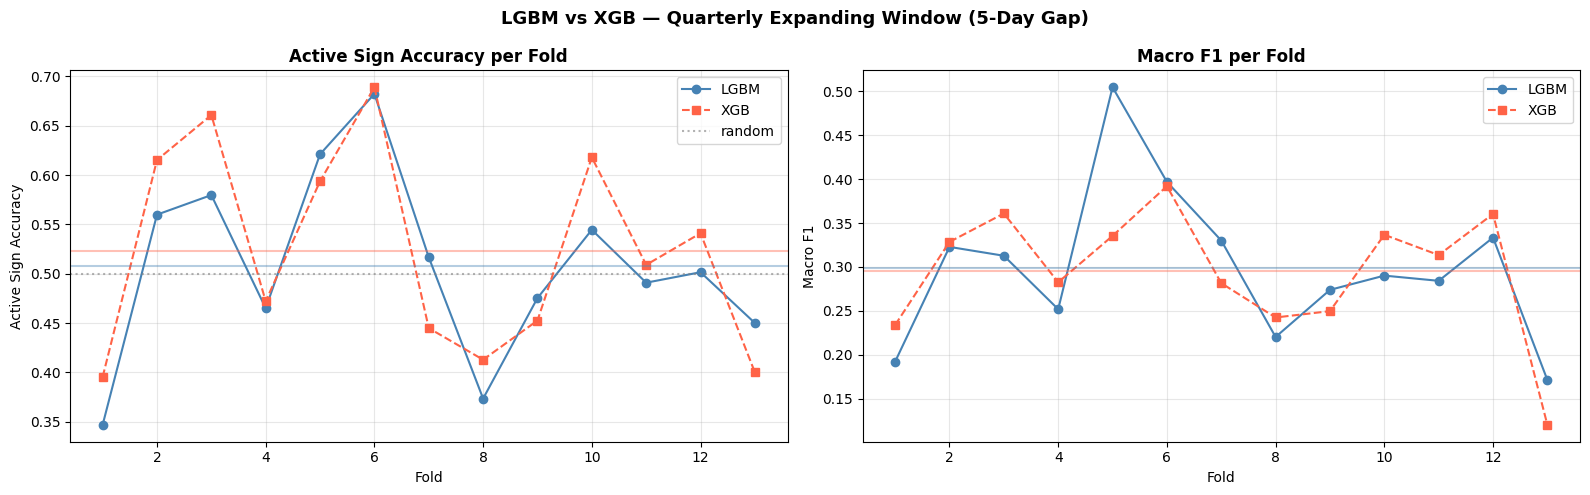

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel in [
    (axes[0], 'active_asa', 'Active Sign Accuracy'),
    (axes[1], 'macro_f1',   'Macro F1'),
]:
    ax.plot(lgb_wf.index, lgb_wf[metric], marker='o', label='LGBM', color='steelblue')
    ax.plot(xgb_wf.index, xgb_wf[metric], marker='s', label='XGB',  color='tomato', linestyle='--')
    ax.axhline(lgb_wf[metric].mean(), color='steelblue', alpha=0.4, linewidth=1.5)
    ax.axhline(xgb_wf[metric].mean(), color='tomato',    alpha=0.4, linewidth=1.5)
    if metric == 'active_asa':
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='random')
    ax.set_title(f'{ylabel} per Fold', fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('LGBM vs XGB — Quarterly Expanding Window (5-Day Gap)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()